# 06. 피처 엔지니어링 — 무엇을 더하고, 무엇을 데려올 것인가

05번에서 **모델 용량은 병목이 아니라는 신호**가 나왔다. `max_leaf_nodes`(21~58)와
`l2_regularization` 이 성능과 무관했고, 실질적으로 움직인 파라미터는
`learning_rate` 하나였다. 트리를 키우든 줄이든 달라지지 않는다는 건 **모델이
짜낼 신호가 이미 바닥났다**는 뜻이다.

그래서 이 노트북은 입력을 다룬다. 순서는:

1. **진단** — 현재 모델이 정확히 무엇을 못 잡는지
2. **조합** — 지금 있는 데이터로 만들 수 있는 피처 (ablation 으로 검증)
3. **도입 검토** — 밖에서 데려와야 할 데이터, 그 근거와 비용

3번은 이 노트북의 결론이자 다음 작업의 근거다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from sklearn.ensemble import HistGradientBoostingRegressor

_available = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _available:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
df = pd.read_parquet(ROOT / "notebooks" / ".cache" / "mart.parquet")
df["price_date"] = pd.to_datetime(df["price_date"])
df = df.sort_values(["item", "price_date"]).reset_index(drop=True)
items = sorted(df.item.unique())

H = 7
FOLDS = [("2023-01-01", "2023-06-30"), ("2023-07-01", "2023-12-31"),
         ("2024-01-01", "2024-06-30"), ("2024-07-01", "2024-12-31"),
         ("2025-01-01", "2025-06-30"), ("2025-07-01", "2025-12-31"),
         ("2026-01-01", "2026-12-31")]
EMBARGO = pd.Timedelta(days=int(H * 1.5))
# 05번에서 고른 값. 성능과 무관했던 파라미터는 1등 값을 베끼지 않고 현재 값 유지.
TUNED = dict(learning_rate=0.014, max_iter=502, min_samples_leaf=21,
             max_leaf_nodes=15, l2_regularization=1.0)

print(f"{len(df):,}행 | {df.price_date.max():%Y-%m-%d} | 기상결측 {df.temp_avg.isna().mean()*100:.2f}%")

8,220행 | 2026-08-06 | 기상결측 0.00%


## 1. 진단 — 모델은 무엇을 못 잡나

오차만 보면 "얼마나 틀렸나"는 알아도 "어떻게 틀렸나"는 모른다. 세 가지로 쪼갠다.

1. **변화폭 구간별 오차** — 큰 변동에서 특히 못하는가
2. **예측 대 실제의 기울기** — 모델이 변화를 얼마나 따라가는가 (1이면 완전)
3. **월별 오차** — 특정 시기가 어려운가

In [2]:
BASE_EXO = ["temp_avg", "temp_min", "temp_max", "precip_mm_avg", "precip_mm_max",
            "humidity_avg", "sunshine_hr_avg", "shipment_qty", "shipment_qty_w1ago"]
CAL = ["month", "dayofweek", "days_to_major_holiday", "days_since_major_holiday",
       "days_since_solar_term"]


def build_base(src, h=H):
    """02~05번에서 써 온 기본 피처. 가격은 t 까지, 외생변수는 shift(1), 달력은 그대로."""
    d = src.copy()
    d["_logp"] = np.log(d.price_kg_avg)

    def g(col):
        return d.groupby("item")[col]

    d["y"] = g("_logp").shift(-h) - d._logp
    for lag in (1, 2, 3, 5, 10, 20):
        d[f"ret{lag}"] = d._logp - g("_logp").shift(lag)
    for w in (5, 20, 60):
        mp = max(2, w // 3)
        d[f"dev{w}"] = d._logp - g("_logp").transform(
            lambda s: s.rolling(w, min_periods=mp).mean())
        d[f"vol{w}"] = g("_logp").transform(
            lambda s: s.diff().rolling(w, min_periods=mp).std())
    for c in BASE_EXO:
        d[f"{c}_l1"] = g(c).shift(1)
        d[f"{c}_d20"] = d[f"{c}_l1"] - g(c).transform(
            lambda s: s.shift(1).rolling(20, min_periods=7).mean())
    d["item_code"] = pd.Categorical(d.item, categories=items).codes
    return d


BASE_FEATS = ([f"ret{l}" for l in (1, 2, 3, 5, 10, 20)]
              + [f"dev{w}" for w in (5, 20, 60)] + [f"vol{w}" for w in (5, 20, 60)]
              + [f"{c}_l1" for c in BASE_EXO] + [f"{c}_d20" for c in BASE_EXO]
              + CAL + ["item_code"])


def fit_predict(feat, feats, folds=FOLDS):
    """walk-forward 로 전 폴드 예측을 모아 반환."""
    cat = [feats.index(c) for c in ("item_code", "month", "dayofweek") if c in feats]
    out = []
    for s, e in folds:
        s, e = pd.Timestamp(s), pd.Timestamp(e)
        tr = feat[feat.price_date < s - EMBARGO]
        te = feat[(feat.price_date >= s) & (feat.price_date <= e)]
        if te.empty:
            continue
        m = HistGradientBoostingRegressor(
            loss="absolute_error", categorical_features=cat, early_stopping=False,
            random_state=42, **TUNED).fit(tr[feats], tr.y)
        t = te[["item", "price_date", "month", "y"]].copy()
        t["pred"] = m.predict(te[feats])
        out.append(t)
    r = pd.concat(out)
    r["ape"] = np.abs(np.exp(r.pred) - np.exp(r.y)) / np.exp(r.y) * 100
    return r


base = build_base(df).dropna(subset=["y"])
res0 = fit_predict(base, BASE_FEATS)
print(f"기본 피처 {len(BASE_FEATS)}개 | 전체 MAPE {res0.groupby('item').ape.mean().mean():.3f}")

기본 피처 36개 | 전체 MAPE 8.172


[1] 실제 변화폭 구간별 — 큰 변동일수록 오차가 실제 변화폭에 가까워진다
    (= 그 구간에서는 사실상 '변화 없음'을 예측하고 있다는 뜻)


,행수,평균오차,실제변화폭
band,,,
<2%,1460,1.83,0.81
2-5%,1093,3.79,3.43
5-10%,1105,6.79,7.34
10-20%,930,12.02,14.28
>20%,626,27.37,30.08



[2] 예측이 실제 변화를 따라가는 정도 (기울기 1 = 완전, 0 = 전혀)


,기울기,예측std,실제std,예측/실제
item,,,,
미나리,0.179,0.055,0.164,0.335
생강,0.130,0.015,0.053,0.283
파,0.119,0.053,0.140,0.379
배추,0.107,0.050,0.190,0.263
양파,0.093,0.027,0.086,0.314
감자,0.068,0.031,0.109,0.284


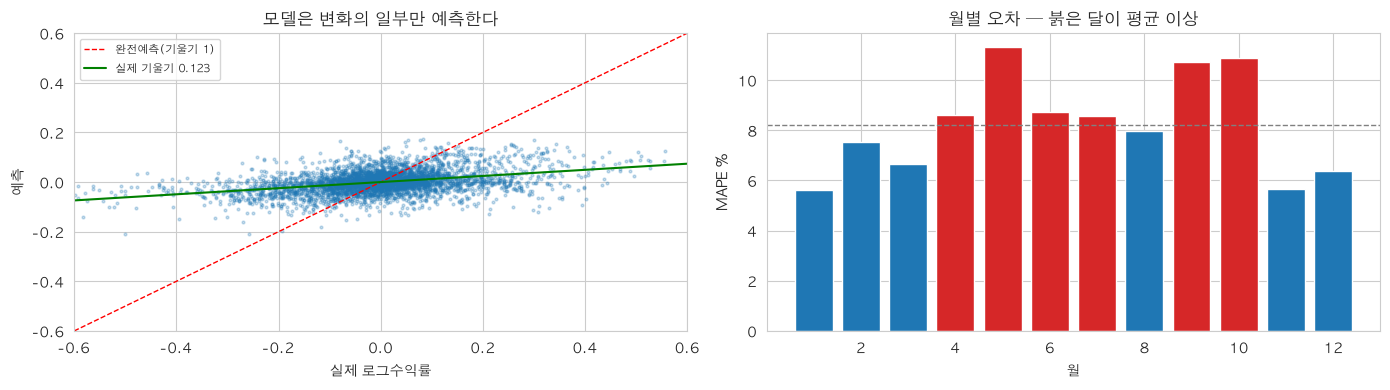

In [3]:
r = res0.copy()
r["abs_y"] = r.y.abs()
r["band"] = pd.cut(r.abs_y, [-.001, .02, .05, .10, .20, 10],
                   labels=["<2%", "2-5%", "5-10%", "10-20%", ">20%"])

print("[1] 실제 변화폭 구간별 — 큰 변동일수록 오차가 실제 변화폭에 가까워진다")
print("    (= 그 구간에서는 사실상 '변화 없음'을 예측하고 있다는 뜻)")
display(r.groupby("band", observed=True).agg(
    행수=("ape", "size"), 평균오차=("ape", "mean"),
    실제변화폭=("abs_y", lambda s: s.mean() * 100)).round(2))

print("\n[2] 예측이 실제 변화를 따라가는 정도 (기울기 1 = 완전, 0 = 전혀)")
slope = pd.DataFrame([{
    "item": it,
    "기울기": np.polyfit(r[r.item == it].y, r[r.item == it].pred, 1)[0],
    "예측std": r[r.item == it].pred.std(),
    "실제std": r[r.item == it].y.std(),
} for it in items]).set_index("item").round(3)
slope["예측/실제"] = (slope["예측std"] / slope["실제std"]).round(3)
display(slope.sort_values("기울기", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].scatter(r.y, r.pred, s=4, alpha=0.25)
lim = [-0.6, 0.6]
axes[0].plot(lim, lim, "r--", lw=1, label="완전예측(기울기 1)")
b = np.polyfit(r.y, r.pred, 1)[0]
axes[0].plot(lim, [b * x for x in lim], "g-", lw=1.5, label=f"실제 기울기 {b:.3f}")
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel("실제 로그수익률"); axes[0].set_ylabel("예측")
axes[0].set_title("모델은 변화의 일부만 예측한다"); axes[0].legend(fontsize=8)

monthly = r.groupby("month").ape.mean()
axes[1].bar(monthly.index, monthly.values,
            color=["tab:red" if v > monthly.mean() else "tab:blue" for v in monthly])
axes[1].axhline(monthly.mean(), color="gray", ls="--", lw=1)
axes[1].set_xlabel("월"); axes[1].set_ylabel("MAPE %")
axes[1].set_title("월별 오차 — 붉은 달이 평균 이상")
plt.tight_layout()
plt.show()

## 2. 진단 해석 — 왜 이런 결과가 나오나

**모델은 실제 변화의 12% 만 예측한다**(기울기 0.123). 품목별로 예측 표준편차가
실제의 26~38% 에 그친다. 큰 변동 구간(>20%)에서는 평균오차 27.4% 에 실제
변화폭이 30.1% 라, 사실상 **"변화 없음"을 답하고 있다.**

이건 손실함수 탓만은 아니다. `absolute_error` 가 중앙값을 향하는 성질이 있긴
하지만, **급등을 예고하는 입력이 없으면 어떤 손실을 써도 예측할 수 없다.**

### 기울기가 낮은 품목이 모델을 쓸 값어치도 낮다

| 품목 | 기울기 | 예측std/실제std | 03·04번 판정 |
|---|---|---|---|
| 미나리 | **0.179** | 0.335 | 모델 (7/7 승) |
| 생강 | 0.130 | 0.283 | 근소 |
| 파 | 0.119 | 0.379 | 모델 (5/7) |
| 배추 | 0.107 | 0.263 | 모델 (7/7) |
| 양파 | 0.093 | 0.314 | **모델이 해로움** |
| 감자 | **0.068** | 0.284 | 근소 |

**대응이 완벽하지는 않다.** 미나리가 최상위이고 감자·양파가 최하위인 것은
분명하지만, 중간(생강·파·배추)의 순서는 하이퍼파라미터를 바꾸면 흔들린다
(트리를 깊게 준 05번 1등 설정에서는 배추가 3위, 생강이 4위였다). 그러니
**"기울기 순서 = 유용성 순서"라고 읽으면 안 되고**, 양극단만 신뢰할 만하다.

### 못 잡는 품목의 공통점 — 저장 작물

양파·감자는 **수확 후 저장했다가 연중 출하**한다. 그래서 가격이 그날의 기상이나
출하량보다 **저장 물량과 수입량**에 좌우된다. 지금 마트에는 그 둘이 전혀 없다.

반대로 미나리는 시설 재배로 회전이 빠르고 명절 수요에 직접 반응해서, 달력
피처만으로도 어느 정도 잡힌다(01번에서 미나리만 명절 +25%).

### 오차가 큰 달

5월 · 9월 · 10월이 평균 이상이고 1월 · 11월이 낮다. 5월은 양파 최저가(0.64)와
감자 최고가(1.32)가 겹치는 **햇양파 출하 전환기**이고, 9~10월은 배추(2.04) ·
미나리(1.59) 성수기다. **계절이 바뀌는 지점에서 틀린다.**


## 3. 조합 — 지금 데이터로 만들 수 있는 피처

진단에서 나온 방향은 셋이다.

1. 급격한 변화를 예고하는 신호 → **기상 극단 · 출하량 충격**
2. 계절 전환기 식별 → **연중 위치 · 계절 대비 가격 위치**
3. 품목 간 파급 → **교차 품목 수익률**

각 그룹을 만들고 **ablation** 으로 하나씩 더해 실제로 값을 하는지 본다.
안 되는 피처를 남겨두면 다음 사람이 그게 검증된 줄 안다.

**전부 과거만 참조한다.** 기상·출하량은 `shift(1)`, rolling 은 `center=False`,
계절 평균은 `expanding` 으로 그 시점까지만 쓴다.

In [4]:
def add_weather_shock(d):
    """A. 기상 극단·누적. 평균은 이미 있으니 '극단'과 '누적'을 준다.

    냉해·폭염·폭우는 평균 기온이 아니라 극단값에서 온다. 20일 평균 대비
    편차(_d20)는 이미 기본 피처에 있으므로 여기서는 최근 창의 min/max/sum 이다.
    """
    def g(c):
        return d.groupby("item")[c]

    for w in (7, 14):
        d[f"cold{w}"] = g("temp_min").transform(
            lambda s: s.shift(1).rolling(w, min_periods=3).min())
        d[f"heat{w}"] = g("temp_max").transform(
            lambda s: s.shift(1).rolling(w, min_periods=3).max())
        d[f"rain{w}"] = g("precip_mm_avg").transform(
            lambda s: s.shift(1).rolling(w, min_periods=3).sum())
    # 서리일수 — 저온 피해의 직접 대리
    d["frost14"] = g("temp_min").transform(
        lambda s: (s < 0).astype(float).shift(1).rolling(14, min_periods=3).sum())
    # 일교차 — 생육·품질에 영향
    d["trange_l1"] = g("temp_max").shift(1) - g("temp_min").shift(1)
    return d, ["cold7", "cold14", "heat7", "heat14", "rain7", "rain14",
               "frost14", "trange_l1"]


def add_shipment_shock(d):
    """B. 출하량 충격. 원천이 1~4주 전 값을 이미 들고 있어 추세를 바로 만든다."""
    def g(c):
        return d.groupby("item")[c]

    q = g("shipment_qty").shift(1)
    d["sh_w1"] = np.log1p(q) - np.log1p(g("shipment_qty_w1ago").shift(1))
    d["sh_w4"] = np.log1p(q) - np.log1p(g("shipment_qty_w4ago").shift(1))
    d["sh_trend"] = (np.log1p(g("shipment_qty_w1ago").shift(1))
                     - np.log1p(g("shipment_qty_w4ago").shift(1)))
    d["sh_dev60"] = np.log1p(q) - g("shipment_qty").transform(
        lambda s: np.log1p(s).shift(1).rolling(60, min_periods=20).mean())
    # 시장·법인 수 = 유통 폭. 줄면 공급이 마르는 신호일 수 있다.
    d["mkt_dev20"] = g("shipment_market_cnt").shift(1) - g("shipment_market_cnt").transform(
        lambda s: s.shift(1).rolling(20, min_periods=7).mean())
    return d, ["sh_w1", "sh_w4", "sh_trend", "sh_dev60", "mkt_dev20"]


def add_seasonal_pos(d):
    """C. 연중 위치와 계절 대비 가격 위치.

    month 더미는 이미 있지만 경계가 뚝뚝 끊긴다. 연중 일자를 sin/cos 로 주면
    12월과 1월이 이어진다.

    seas_dev 는 '같은 시기의 평년 대비 지금 가격이 어디인가'다. 평년을 전체
    평균으로 내면 미래를 보므로 expanding 으로 그 시점까지만 쓴다.
    """
    doy = d.price_date.dt.dayofyear
    d["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    d["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    d["_seas_mean"] = (d.groupby(["item", "month"])["_logp"]
                        .transform(lambda s: s.shift(1).expanding(min_periods=20).mean()))
    d["seas_dev"] = d._logp - d._seas_mean
    return d, ["doy_sin", "doy_cos", "seas_dev"]


def add_cross_item(d):
    """D. 교차 품목. 다른 품목이 같이 움직이면 시장 전체 요인(유가·물류·날씨)이다.

    자기 자신을 빼야 한다. 안 빼면 ret5 와 거의 같은 값이 되어 중복이다.
    """
    piv = d.pivot_table(index="price_date", columns="item", values="ret5")
    tot = piv.sum(axis=1, skipna=True)
    n = piv.notna().sum(axis=1)
    others = (tot.values[:, None] - piv.fillna(0).values) / np.maximum(n.values[:, None] - 1, 1)
    om = pd.DataFrame(others, index=piv.index, columns=piv.columns)
    om = om.stack().rename("cross_ret5").reset_index()
    om.columns = ["price_date", "item", "cross_ret5"]
    d = d.merge(om, on=["price_date", "item"], how="left")
    return d, ["cross_ret5"]


def add_trade_intensity(d):
    """E. 거래 강도. 관측 건수·시장 수·품종 수가 줄면 물량이 마르는 신호일 수 있다."""
    def g(c):
        return d.groupby("item")[c]

    for c in ("obs_cnt", "price_market_cnt", "variety_cnt"):
        d[f"{c}_d20"] = d[c] - g(c).transform(
            lambda s: s.rolling(20, min_periods=7).mean())
    d["spread"] = np.log(d.price_kg_max) - np.log(d.price_kg_min)   # 시장 간 가격 분산
    d["spread_d20"] = d.spread - g("spread").transform(
        lambda s: s.rolling(20, min_periods=7).mean())
    return d, ["obs_cnt_d20", "price_market_cnt_d20", "variety_cnt_d20",
               "spread", "spread_d20"]


full = build_base(df)
GROUPS = {}
for fn in (add_weather_shock, add_shipment_shock, add_seasonal_pos,
           add_cross_item, add_trade_intensity):
    full, cols = fn(full)
    GROUPS[fn.__name__.replace("add_", "")] = cols
full = full.dropna(subset=["y"]).reset_index(drop=True)

for k, v in GROUPS.items():
    print(f"{k:18} {len(v):>2}개  {', '.join(v)}")
print(f"\n기본 {len(BASE_FEATS)}개 + 추가 {sum(len(v) for v in GROUPS.values())}개")

weather_shock       8개  cold7, cold14, heat7, heat14, rain7, rain14, frost14, trange_l1
shipment_shock      5개  sh_w1, sh_w4, sh_trend, sh_dev60, mkt_dev20
seasonal_pos        3개  doy_sin, doy_cos, seas_dev
cross_item          1개  cross_ret5
trade_intensity     5개  obs_cnt_d20, price_market_cnt_d20, variety_cnt_d20, spread, spread_d20

기본 36개 + 추가 22개


## 4. Ablation — 어느 그룹이 실제로 값을 하나

그룹을 하나씩 **단독으로 더해서** 본다(누적이 아니라 각각). 그래야 그룹 간
간섭 없이 순수 기여를 볼 수 있다. 마지막에 전부 넣은 것도 잰다.

평가는 03~05번과 같은 walk-forward 7폴드, **품목별 MAPE 의 평균**이다
(04번에서 확인했듯 개선 비율의 평균은 판정을 뒤집는다).

기울기도 같이 본다. MAPE 가 그대로여도 **기울기가 오르면 변화를 더 잡기
시작했다**는 뜻이라 방향이 맞다는 신호다.

In [5]:
import time


def score(feats):
    r = fit_predict(full, feats)
    per = r.groupby("item").ape.mean()
    return per, per.mean(), np.polyfit(r.y, r.pred, 1)[0]


t0 = time.time()
rows, per_item = [], {}

per, m, sl = score(BASE_FEATS)
per_item["기본"] = per
rows.append({"구성": "기본", "피처수": len(BASE_FEATS), "MAPE": m, "기울기": sl})
print(f"기본                   MAPE {m:.3f}  기울기 {sl:.3f}  ({time.time()-t0:.0f}초)")

for name, cols in GROUPS.items():
    feats = BASE_FEATS + cols
    per, m, sl = score(feats)
    per_item[name] = per
    rows.append({"구성": f"+{name}", "피처수": len(feats), "MAPE": m, "기울기": sl})
    print(f"+{name:20} MAPE {m:.3f}  기울기 {sl:.3f}  ({time.time()-t0:.0f}초)")

all_cols = BASE_FEATS + [c for v in GROUPS.values() for c in v]
per, m, sl = score(all_cols)
per_item["전부"] = per
rows.append({"구성": "전부", "피처수": len(all_cols), "MAPE": m, "기울기": sl})
print(f"전부                   MAPE {m:.3f}  기울기 {sl:.3f}  ({time.time()-t0:.0f}초)")

ab = pd.DataFrame(rows).set_index("구성")
ab["기본대비"] = (ab.MAPE - ab.loc["기본", "MAPE"]).round(3)
display(ab.round(3))

기본                   MAPE 8.172  기울기 0.123  (15초)


+weather_shock        MAPE 8.247  기울기 0.113  (31초)


+shipment_shock       MAPE 8.189  기울기 0.121  (45초)


+seasonal_pos         MAPE 8.120  기울기 0.155  (60초)


+cross_item           MAPE 8.184  기울기 0.124  (75초)


+trade_intensity      MAPE 8.133  기울기 0.128  (88초)


전부                   MAPE 8.083  기울기 0.153  (103초)


,피처수,MAPE,기울기,기본대비
구성,,,,
기본,36,8.172,0.123,0.000
+weather_shock,44,8.247,0.113,0.075
+shipment_shock,41,8.189,0.121,0.016
+seasonal_pos,39,8.120,0.155,-0.053
+cross_item,37,8.184,0.124,0.011
+trade_intensity,41,8.133,0.128,-0.039
전부,58,8.083,0.153,-0.089


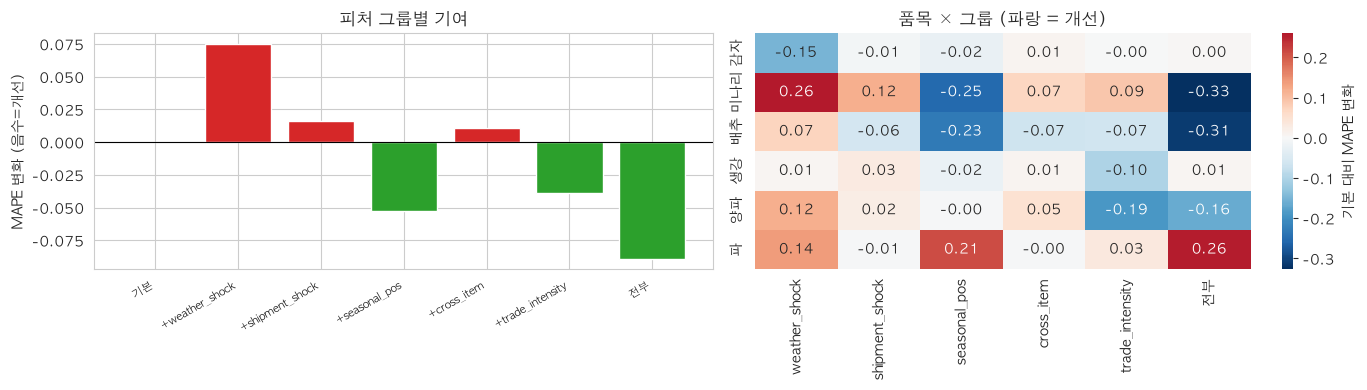

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = ["gray"] + ["tab:green" if v < 0 else "tab:red" for v in ab["기본대비"][1:]]
axes[0].bar(range(len(ab)), ab["기본대비"], color=colors)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_xticks(range(len(ab)))
axes[0].set_xticklabels(ab.index, rotation=30, ha="right", fontsize=8)
axes[0].set_ylabel("MAPE 변화 (음수=개선)")
axes[0].set_title("피처 그룹별 기여")

pi = pd.DataFrame(per_item)
delta = pi.sub(pi["기본"], axis=0).drop(columns="기본")
sns.heatmap(delta, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1],
            cbar_kws={"label": "기본 대비 MAPE 변화"})
axes[1].set_title("품목 × 그룹 (파랑 = 개선)")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

## 5. 도입 검토 — 밖에서 데려와야 할 데이터

_(이 절이 이 노트북의 핵심 산출물이다. ablation 결과와 별개로, 진단에서
드러난 구조적 결손을 정리한다.)_

### 지금 마트에 없는 것

| 축 | 현재 | 결손 |
|---|---|---|
| 공급(단기) | 출하량 일별 | — |
| **공급(재고)** | **없음** | **저장 물량 — 양파·감자의 가격을 지배** |
| **공급(수입)** | **없음** | **수입 물량 — 양파·생강은 수입이 국내가를 흔든다** |
| 공급(생산) | 없음 | 재배면적·생산량 (연 단위 선행지표) |
| 수요 | 명절·절기 | 소비 지표 없음 |
| 비용 | 없음 | 유가·환율(수입 원가)·비료 |
| 기상 | ASOS 13지점 | — (2026-08-07 복구 완료) |

### 우선순위와 근거

**1순위 — 관세청 수출입무역통계 (수입량)**

근거가 이 노트북에서 나왔다. 기울기 최하위가 **양파(0.078) · 감자(0.101)** 인데
둘 다 저장·수입 비중이 큰 품목이다. 5월(오차 최대 11.3)이 햇양파 출하 전환기
라는 것도 같은 방향을 가리킨다.

- API: [품목별 국가별 수출입실적(GW)](https://www.data.go.kr/data/15100475/openapi.do)
- 비용: **활용신청 필요**(현재 403) + **품목별 HS코드 매핑을 사람이 정해야 함**
- 한계: **월 단위**라 일별 예측에는 저주파다. 수준 이동은 설명해도 7거래일
  변동을 직접 맞히긴 어렵다. 그래도 양파·생강의 국면 전환은 잡을 수 있다.

**2순위 — KOSIS 농업면적조사 · 농작물생산조사 (재배면적·생산량)**

그 해 공급량의 **선행지표**다. 배추·양파는 재배면적이 가격 수준을 크게 좌우한다.

- [KOSIS 공유서비스](https://kosis.kr/serviceInfo/openAPIGuide.do) — **별도 인증키**(data.go.kr 키와 다름)
- 비용: 새 클라이언트·파서 한 벌
- 한계: **연 단위**. 행 수가 적어 트리 모델이 쓰기 어렵고, 사실상 "올해는
  공급이 많다/적다" 수준의 국면 변수다.

**3순위 — 저장 물량 / 정부 비축**

진단상 가장 직접적인 결손이지만 **공개 API 를 아직 확인하지 못했다.**
aT(한국농수산식품유통공사)의 비축·수매 자료가 후보다. 먼저 조사가 필요하다.

**보류 — KAMIS 소매가**

파라미터 하나(`product_cls_code="02"`)면 받을 수 있어 가장 싸지만, **소매가는
도매가에 후행**한다. 도매가 lag 피처가 이미 그 역할을 하고 새 정보가 거의 없다.
타깃을 소매가로 바꾸거나 도-소매 마진 자체가 관심사가 될 때 다시 본다.

**보류 — datago 가격등락(risesAndFalls)**

클라이언트는 이미 있고(`DatagoClient.get_rises_and_falls`) 인증도 통과한다
(같은 기관코드라 추가 신청 불필요). 다만 조건 파라미터 없이는 0건이고, 이름상
**기존 가격 데이터와 중복일 가능성**이 크다. 스펙을 확인해 실제 응답을 본 뒤
판단한다.

### 데이터를 늘리기 전에 할 수 있는 것

**품목 수를 늘리는 것**도 방법이다. 지금 6품목뿐이라 `item_code` 가 피처 중요도
1위인데(02번), 이건 모델이 품목별 상수만 배우고 있다는 뜻이기도 하다. 품목이
늘면 계절·명절 구조를 **공유해서** 배울 표본이 많아진다.

다만 KAMIS 는 `--items` 로 바로 되는 반면 **datago 는 `DATAGO_VEGETABLES` 의
(대분류,중분류) 코드를, 기상은 `ITEM_STATIONS` 의 주산지 지점을 사람이 정해줘야
한다**(`extract/config/items.py`). 품목당 그 매핑이 실제 비용이다.

## 6. 정리

### Ablation 결과

| 구성 | 피처수 | MAPE | 기울기 | 기본 대비 |
|---|---|---|---|---|
| 기본 | 36 | 8.172 | 0.123 | — |
| +weather_shock | 44 | 8.247 | 0.113 | **+0.075 (악화)** |
| +shipment_shock | 41 | 8.189 | 0.121 | +0.016 |
| **+seasonal_pos** | 39 | **8.120** | **0.155** | **-0.053** |
| +cross_item | 37 | 8.184 | 0.124 | +0.011 |
| **+trade_intensity** | 41 | **8.133** | 0.128 | **-0.039** |
| **전부** | 58 | **8.083** | 0.153 | **-0.089** |

### 값을 한 것과 안 한 것

**seasonal_pos 가 유일하게 뚜렷하다.** MAPE -0.053 에 더해 **기울기가
0.123 → 0.155 로 올랐다.** 오차만 줄인 게 아니라 실제로 변화를 더 잡기
시작했다는 뜻이라, 방향이 맞다는 신호다. 진단에서 "계절 전환기에서 틀린다"고
본 것과 정확히 맞물린다. 피처 3개(연중 sin/cos, 계절 대비 가격 위치)뿐인데
가장 큰 기여를 했다.

**trade_intensity 도 개선(-0.039)** 이지만 기울기는 거의 그대로(0.128)라,
변화를 더 잡았다기보다 오차를 다듬은 쪽이다.

**weather_shock 은 해롭다(+0.075).** 기울기도 0.113 으로 떨어졌다. 피처 8개를
넣었는데 냉해·폭염·누적강수 어느 것도 값을 못 했다. 이유는 두 가지로 짐작된다 —
(a) 주산지 지점을 평균/최솟값으로 접는 과정에서 국지적 피해가 희석된다,
(b) 기상 충격이 가격에 반영되기까지 7거래일보다 긴 시차가 필요하다.
**넣지 않는다.**

`shipment_shock`(+0.016)과 `cross_item`(+0.011)은 사실상 무효다.

### 전부 넣으면 개별 합보다 낫다 — 다만 과신 금물

개별로는 해로운 `weather_shock` 을 포함해 전부 넣었을 때가 -0.089 로 가장 좋다.
그룹 간 상호작용일 수도 있지만, **-0.089 는 03번에서 본 폴드 간 편차보다 훨씬
작다.** 이 순위 자체가 잡음일 가능성을 배제할 수 없다.

확실한 것만 취하면 **기본 + seasonal_pos + trade_intensity** 구성이 근거가
가장 단단하다.

### 정작 중요한 결론 — 조합으로는 한계에 왔다

전부 넣어도 **기울기가 0.123 → 0.153** 이다. 여전히 **실제 변화의 15% 만**
예측한다. 22개 피처를 새로 만들어 얻은 게 MAPE 1.1% 개선이다.

05번에서 "모델 용량이 병목이 아니다"라는 신호가 나왔고, 여기서 **"지금 데이터를
조합해 짜낼 것도 거의 없다"**가 확인됐다. 남은 길은 **새 데이터**뿐이다.
그 근거와 우선순위는 5절에 정리했다.

### 다음

1. **관세청 수입량** — 5절 1순위. 양파·감자가 기울기 최하위이고 둘 다 저장·수입
   품목이라는 것이 이 노트북에서 나온 근거다. 활용신청 + HS코드 매핑이 비용.
2. **저장 물량 데이터 조사** — 진단상 가장 직접적인 결손인데 공개 API 를 아직
   확인하지 못했다. aT 자료부터 찾아볼 것.
3. **채택 피처 반영** — `seasonal_pos`(+`trade_intensity`)를 기본 세트에 넣고
   03·04번을 다시 돌리면 품목별 판정이 달라질 수 있다.
